<a href="https://colab.research.google.com/github/Harika-1707/Child-height-prediction-using-Machine-learning/blob/main/Child_Height_Prediction_Using_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# CELL 2: UPLOAD DATASET
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving child_adult_height_research_dataset_7000_final.csv to child_adult_height_research_dataset_7000_final (1).csv


In [ ]:
# ============================================================
# CELL 3: LOAD THE DATASET
# ============================================================

import pandas as pd

# Load the cleaned final dataset.
df = pd.read_csv(
    "/content/child_adult_height_research_dataset_7000_final.csv"
)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDataset columns:")
print(df.columns.tolist())

Dataset loaded successfully.
Rows: 7000
Columns: 16

Dataset columns:
['Child_ID', 'Child_Sex', 'Child_Age_Years', 'Child_Current_Height_cm', 'Child_Current_Weight_kg', 'Child_BMI', 'Father_Age_Years', 'Father_Height_cm', 'Mother_Age_Years', 'Mother_Height_cm', 'Mid_Parental_Height_cm', 'Blood_Group', 'Birth_Weight_kg', 'Birth_Length_cm', 'Growth_Velocity_cm_per_year', 'Final_Adult_Height_cm']


In [ ]:
# ==========================================
# CELL 4: FIRST 5 ROWS
# ==========================================

df.head()

,Child_ID,Child_Sex,Child_Age_Years,Child_Current_Height_cm,Child_Current_Weight_kg,Child_BMI,Father_Age_Years,Father_Height_cm,Mother_Age_Years,Mother_Height_cm,Mid_Parental_Height_cm,Blood_Group,Birth_Weight_kg,Birth_Length_cm,Growth_Velocity_cm_per_year,Height_PGS_Synthetic,Final_Adult_Height_cm
0,CH00001,Female,9.48,128.8,26.2,15.81,36.1,157.0,36.7,152.0,152.9,B+,2.82,45.5,5.75,-1.420,147.0
1,CH00002,Female,5.59,136.7,26.8,14.35,44.3,167.4,28.0,161.9,160.7,B+,3.54,50.8,2.34,1.492,170.0
2,CH00003,Male,8.20,133.6,30.9,17.29,49.0,172.4,35.6,149.6,168.0,A+,2.93,47.4,5.80,-0.747,162.4
3,CH00004,Male,7.52,141.5,33.1,16.53,46.2,157.8,32.3,161.2,166.9,O+,2.99,49.8,6.37,1.071,174.7
4,CH00005,Male,13.91,173.2,59.6,19.87,45.7,182.4,38.0,168.4,179.9,O+,3.27,49.5,7.70,1.143,184.8


In [ ]:
# ==========================================
# CELL 5: LAST 5 ROWS
# ==========================================

df.tail()

,Child_ID,Child_Sex,Child_Age_Years,Child_Current_Height_cm,Child_Current_Weight_kg,Child_BMI,Father_Age_Years,Father_Height_cm,Mother_Age_Years,Mother_Height_cm,Mid_Parental_Height_cm,Blood_Group,Birth_Weight_kg,Birth_Length_cm,Growth_Velocity_cm_per_year,Height_PGS_Synthetic,Final_Adult_Height_cm
6995,CH06996,Female,7.78,129.9,32.3,19.13,41.2,169.8,33.2,160.4,161.0,A+,2.82,52.3,5.69,-1.012,158.1
6996,CH06997,Female,16.81,162.9,56.0,21.11,47.3,179.3,34.6,154.7,162.6,A+,3.00,52.4,4.28,0.939,166.0
6997,CH06998,Male,7.48,144.6,41.7,19.95,51.2,169.8,44.6,170.2,176.2,A+,3.24,48.7,6.00,-1.600,175.8
6998,CH06999,Female,5.01,132.8,36.1,20.49,44.3,162.9,35.5,161.9,159.3,B-,2.21,50.0,2.59,1.153,167.0
6999,CH07000,Female,8.92,137.3,35.1,18.65,32.0,182.3,28.0,158.0,164.1,B+,4.31,47.9,7.21,0.205,165.7


In [ ]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Columns in the dataset:

1 : Child_ID
2 : Child_Sex
3 : Child_Age_Years
4 : Child_Current_Height_cm
5 : Child_Current_Weight_kg
6 : Child_BMI
7 : Father_Age_Years
8 : Father_Height_cm
9 : Mother_Age_Years
10 : Mother_Height_cm
11 : Mid_Parental_Height_cm
12 : Blood_Group
13 : Birth_Weight_kg
14 : Birth_Length_cm
15 : Growth_Velocity_cm_per_year
16 : Height_PGS_Synthetic
17 : Final_Adult_Height_cm


In [ ]:
df.dtypes

,0
Child_ID,object
Child_Sex,object
Child_Age_Years,float64
Child_Current_Height_cm,float64
Child_Current_Weight_kg,float64
Child_BMI,float64
Father_Age_Years,float64
Father_Height_cm,float64
Mother_Age_Years,float64
Mother_Height_cm,float64


In [ ]:
df.describe()

,Child_Age_Years,Child_Current_Height_cm,Child_Current_Weight_kg,Child_BMI,Father_Age_Years,Father_Height_cm,Mother_Age_Years,Mother_Height_cm,Mid_Parental_Height_cm,Birth_Weight_kg,Birth_Length_cm,Growth_Velocity_cm_per_year,Height_PGS_Synthetic,Final_Adult_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,11.077073,147.323614,39.222471,17.824834,41.902443,171.686786,38.580229,158.497486,166.183657,3.144430,49.464886,6.979991,-0.000003,166.235729
std,3.449709,13.224661,9.571851,2.236598,5.473598,7.054420,4.904815,6.420338,6.369716,0.484058,2.172436,2.364286,1.000076,9.245760
min,5.000000,110.100000,15.100000,12.000000,30.000000,150.000000,28.000000,140.000000,148.500000,1.800000,43.000000,1.000000,-3.518000,140.000000
25%,8.140000,137.475000,32.100000,16.300000,38.100000,166.800000,35.200000,154.200000,161.000000,2.820000,48.000000,5.040000,-0.683250,159.400000
50%,11.100000,146.900000,38.300000,17.810000,41.800000,171.600000,38.550000,158.500000,166.100000,3.150000,49.500000,7.010000,-0.003000,166.200000
75%,14.060000,156.925000,45.600000,19.330000,45.700000,176.500000,42.000000,162.800000,171.300000,3.470000,50.900000,8.910000,0.690000,173.100000
max,17.000000,185.400000,76.200000,25.660000,60.000000,195.000000,57.100000,180.000000,184.600000,4.800000,56.000000,12.000000,3.744000,198.700000


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

Child_ID                       0
Child_Sex                      0
Child_Age_Years                0
Child_Current_Height_cm        0
Child_Current_Weight_kg        0
Child_BMI                      0
Father_Age_Years               0
Father_Height_cm               0
Mother_Age_Years               0
Mother_Height_cm               0
Mid_Parental_Height_cm         0
Blood_Group                    0
Birth_Weight_kg                0
Birth_Length_cm                0
Growth_Velocity_cm_per_year    0
Height_PGS_Synthetic           0
Final_Adult_Height_cm          0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
print(df["Child_Sex"].value_counts())

Child_Sex
Female    3522
Male      3478
Name: count, dtype: int64


In [ ]:
print(df["Blood_Group"].value_counts())

Blood_Group
O+     2675
A+     1915
B+     1865
AB+     279
O-       95
A-       69
B-       63
AB-      39
Name: count, dtype: int64


In [ ]:
print(df["Final_Adult_Height_cm"].describe())

count    7000.000000
mean      166.235729
std         9.245760
min       140.000000
25%       159.400000
50%       166.200000
75%       173.100000
max       198.700000
Name: Final_Adult_Height_cm, dtype: float64


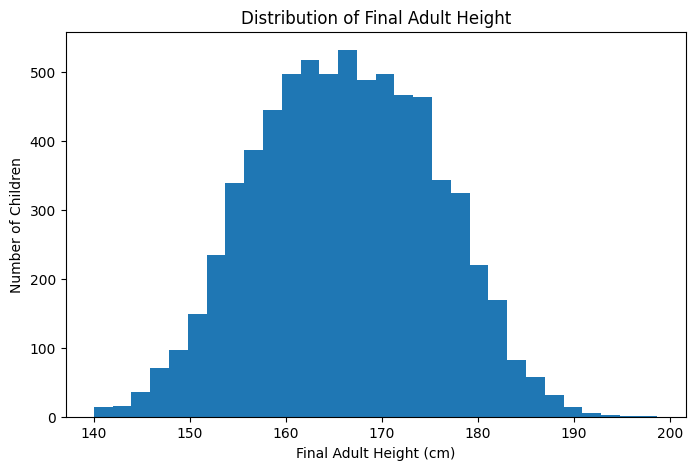

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Final_Adult_Height_cm"], bins=30)

plt.xlabel("Final Adult Height (cm)")
plt.ylabel("Number of Children")
plt.title("Distribution of Final Adult Height")

plt.show()

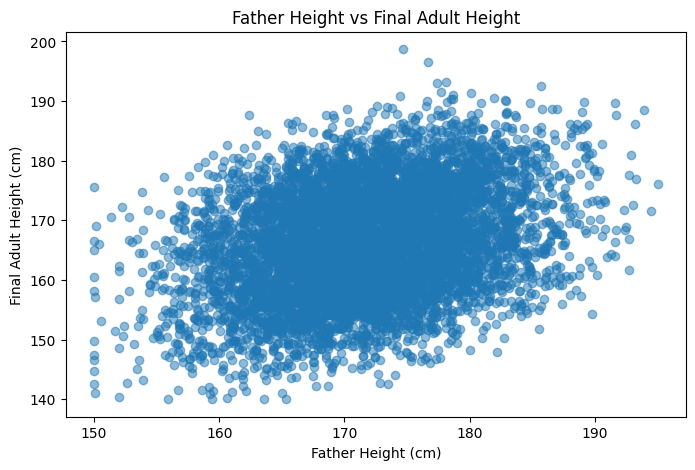

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Father_Height_cm"],
    df["Final_Adult_Height_cm"],
    alpha=0.5
)

plt.xlabel("Father Height (cm)")
plt.ylabel("Final Adult Height (cm)")
plt.title("Father Height vs Final Adult Height")

plt.show()



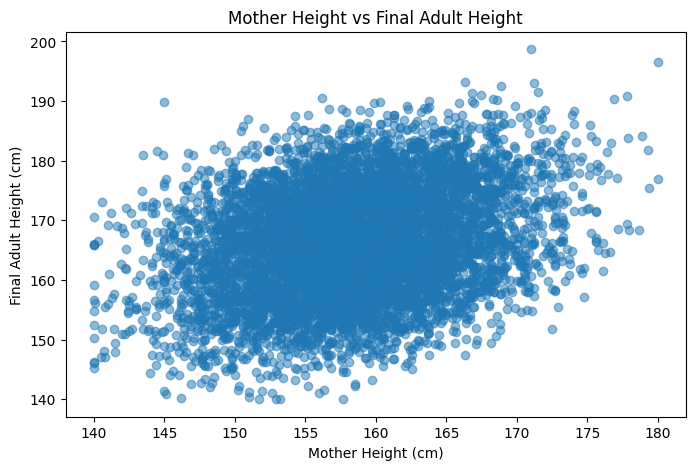

In [ ]:

plt.figure(figsize=(8,5))

plt.scatter(
    df["Mother_Height_cm"],
    df["Final_Adult_Height_cm"],
    alpha=0.5
)

plt.xlabel("Mother Height (cm)")
plt.ylabel("Final Adult Height (cm)")
plt.title("Mother Height vs Final Adult Height")

plt.show()

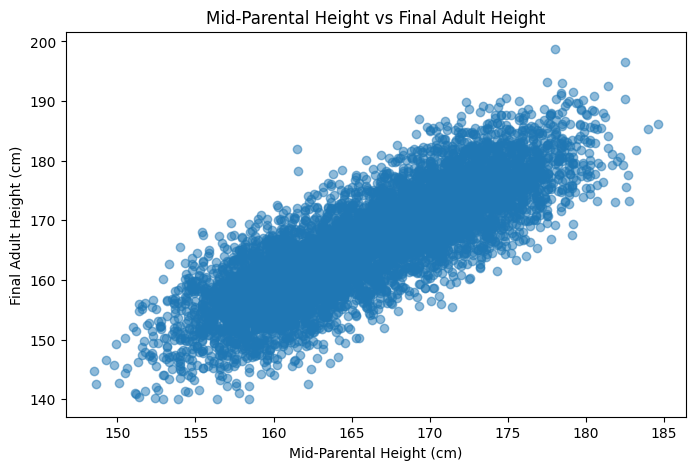

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Mid_Parental_Height_cm"],
    df["Final_Adult_Height_cm"],
    alpha=0.5
)

plt.xlabel("Mid-Parental Height (cm)")
plt.ylabel("Final Adult Height (cm)")
plt.title("Mid-Parental Height vs Final Adult Height")

plt.show()

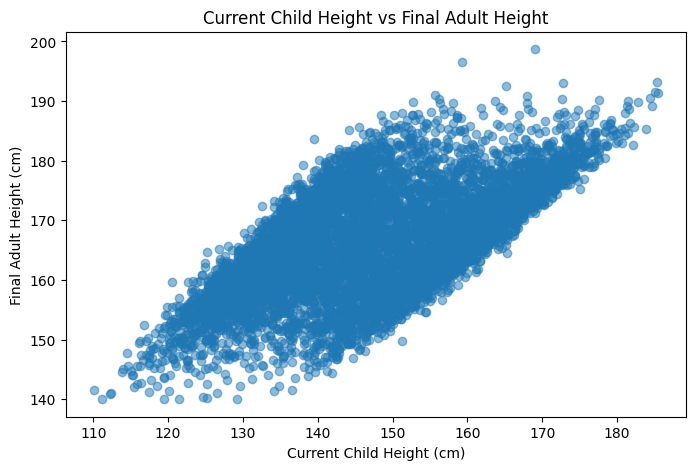

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Child_Current_Height_cm"],
    df["Final_Adult_Height_cm"],
    alpha=0.5
)

plt.xlabel("Current Child Height (cm)")
plt.ylabel("Final Adult Height (cm)")
plt.title("Current Child Height vs Final Adult Height")

plt.show()

In [ ]:
blood_group_height = df.groupby("Blood_Group")["Final_Adult_Height_cm"].mean()

print(blood_group_height)

Blood_Group
A+     165.996240
A-     165.646377
AB+    166.185305
AB-    165.015385
B+     166.454102
B-     166.273016
O+     166.285533
O-     166.426316
Name: Final_Adult_Height_cm, dtype: float64


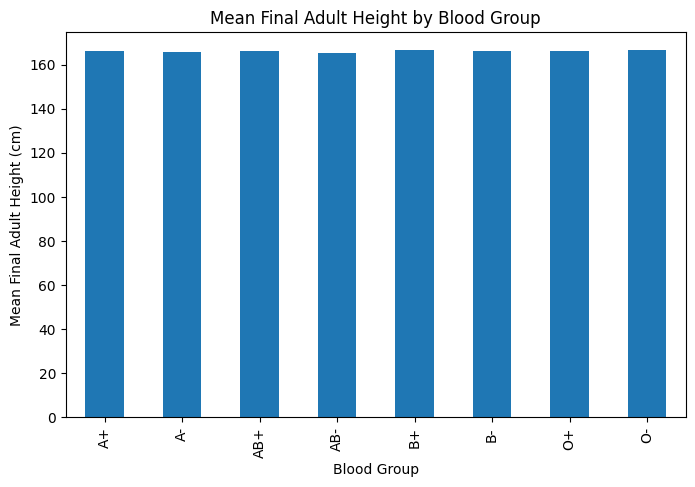

In [ ]:
blood_group_height.plot(kind="bar", figsize=(8,5))

plt.xlabel("Blood Group")
plt.ylabel("Mean Final Adult Height (cm)")
plt.title("Mean Final Adult Height by Blood Group")

plt.show()

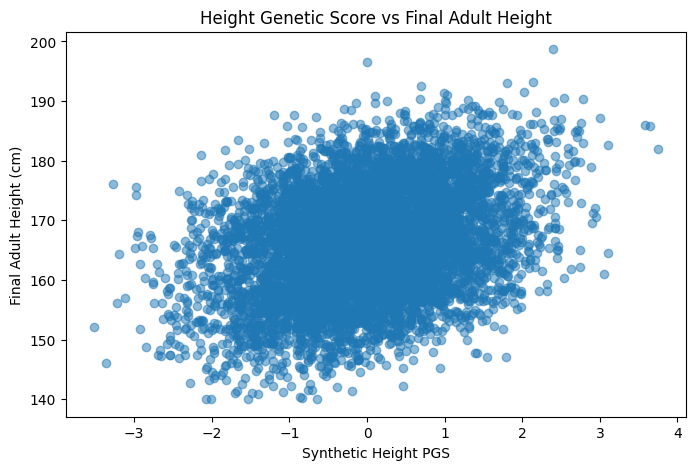

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Height_PGS_Synthetic"],
    df["Final_Adult_Height_cm"],
    alpha=0.5
)

plt.xlabel("Synthetic Height PGS")
plt.ylabel("Final Adult Height (cm)")
plt.title("Height Genetic Score vs Final Adult Height")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Child_Age_Years,Child_Current_Height_cm,Child_Current_Weight_kg,Child_BMI,Father_Age_Years,Father_Height_cm,Mother_Age_Years,Mother_Height_cm,Mid_Parental_Height_cm,Birth_Weight_kg,Birth_Length_cm,Growth_Velocity_cm_per_year,Height_PGS_Synthetic,Final_Adult_Height_cm
Child_Age_Years,1.000000,0.762907,0.725718,0.329625,0.004773,0.009029,-0.004399,0.008642,0.004566,0.005485,0.004508,0.176342,-0.010628,-0.001458
Child_Current_Height_cm,0.762907,1.000000,0.862817,0.255712,0.035020,0.202221,0.014503,0.185802,0.513213,0.015682,0.015896,0.175339,0.195591,0.616872
Child_Current_Weight_kg,0.725718,0.862817,1.000000,0.698361,0.025524,0.159646,0.012548,0.142804,0.377151,0.003849,0.013565,0.122921,0.136368,0.451451
Child_BMI,0.329625,0.255712,0.698361,1.000000,0.000807,0.025009,0.000387,0.013284,0.004619,-0.014149,0.007650,0.041263,-0.011522,0.001550
Father_Age_Years,0.004773,0.035020,0.025524,0.000807,1.000000,0.002037,0.002597,0.001517,0.046596,-0.001778,0.008875,0.001019,0.009846,0.049970
Father_Height_cm,0.009029,0.202221,0.159646,0.025009,0.002037,1.000000,0.000399,-0.007065,0.438251,0.022299,0.012282,-0.012511,0.018138,0.318054
Mother_Age_Years,-0.004399,0.014503,0.012548,0.000387,0.002597,0.000399,1.000000,0.003902,0.023088,-0.009587,-0.014551,0.003604,0.005383,0.021564
Mother_Height_cm,0.008642,0.185802,0.142804,0.013284,0.001517,-0.007065,0.003902,1.000000,0.417061,-0.014282,0.005027,-0.023695,0.009901,0.297445
Mid_Parental_Height_cm,0.004566,0.513213,0.377151,0.004619,0.046596,0.438251,0.023088,0.417061,1.000000,0.013184,0.020813,0.055571,0.009653,0.827583
Birth_Weight_kg,0.005485,0.015682,0.003849,-0.014149,-0.001778,0.022299,-0.009587,-0.014282,0.013184,1.000000,-0.014162,0.000567,-0.011111,0.016866


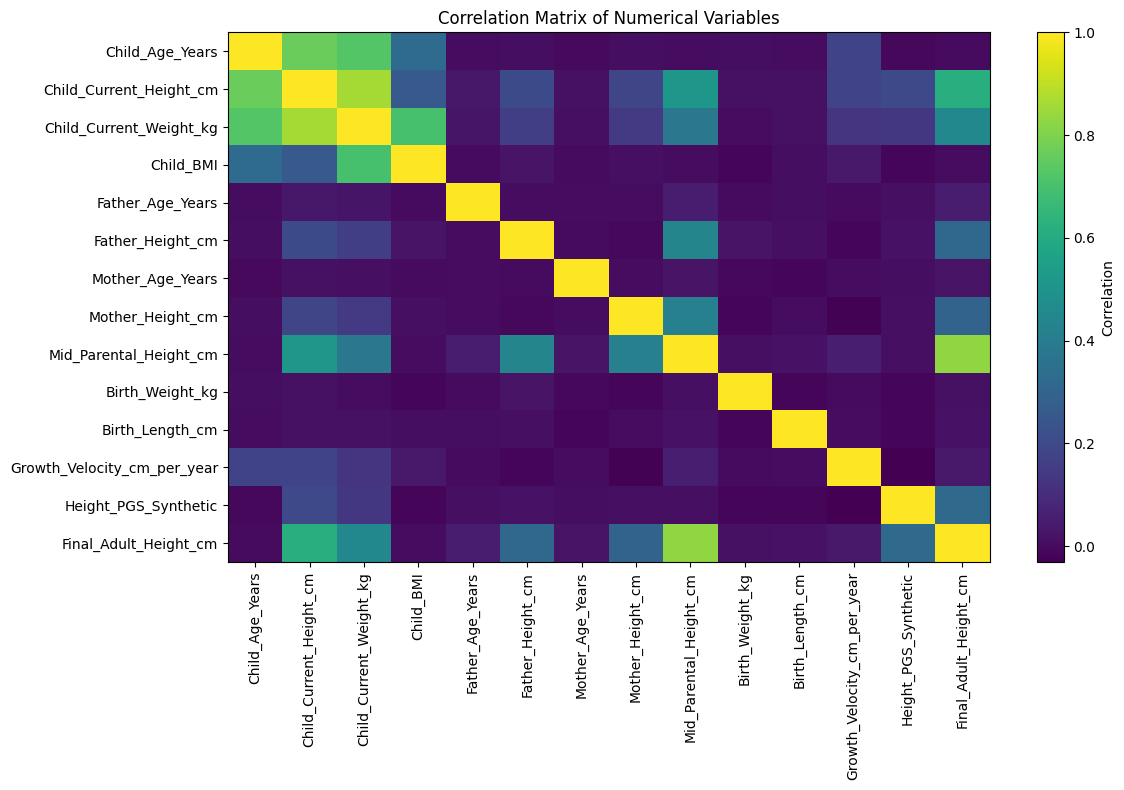

In [ ]:
plt.figure(figsize=(12,8))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

In [ ]:
print("Minimum child age:", df["Child_Age_Years"].min())
print("Maximum child age:", df["Child_Age_Years"].max())

print("Minimum current height:", df["Child_Current_Height_cm"].min())
print("Maximum current height:", df["Child_Current_Height_cm"].max())

print("Minimum final adult height:", df["Final_Adult_Height_cm"].min())
print("Maximum final adult height:", df["Final_Adult_Height_cm"].max())

print("Minimum BMI:", df["Child_BMI"].min())
print("Maximum BMI:", df["Child_BMI"].max())

Minimum child age: 5.0
Maximum child age: 17.0
Minimum current height: 110.1
Maximum current height: 185.4
Minimum final adult height: 140.0
Maximum final adult height: 198.7
Minimum BMI: 12.0
Maximum BMI: 25.66


In [ ]:
# ============================================================
# CELL 21: DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

# The target is the final adult height that we want to predict.
target = "Final_Adult_Height_cm"

# X contains all information that will be given to the ML model.
# We remove:
# 1. Final_Adult_Height_cm -> because this is our target
# 2. Child_ID -> because an ID has no biological predictive meaning
X = df.drop(columns=[target, "Child_ID"])

# y contains only the value that we want the model to predict.
y = df[target]

# Display the size of X and y so we can verify the separation.
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nTarget variable:", target)

Features (X) shape: (7000, 15)
Target (y) shape: (7000,)

Target variable: Final_Adult_Height_cm


In [ ]:
# ============================================================
# CELL 22: IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

# These columns contain categories/text rather than continuous numbers.
categorical_features = [
    "Child_Sex",
    "Blood_Group"
]

# These columns contain numerical measurements.
numerical_features = [
    "Child_Age_Years",
    "Child_Current_Height_cm",
    "Child_Current_Weight_kg",
    "Child_BMI",
    "Father_Age_Years",
    "Father_Height_cm",
    "Mother_Age_Years",
    "Mother_Height_cm",
    "Mid_Parental_Height_cm",
    "Birth_Weight_kg",
    "Birth_Length_cm",
    "Growth_Velocity_cm_per_year",
    "Height_PGS_Synthetic"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Child_Sex', 'Blood_Group']

Numerical features:
['Child_Age_Years', 'Child_Current_Height_cm', 'Child_Current_Weight_kg', 'Child_BMI', 'Father_Age_Years', 'Father_Height_cm', 'Mother_Age_Years', 'Mother_Height_cm', 'Mid_Parental_Height_cm', 'Birth_Weight_kg', 'Birth_Length_cm', 'Growth_Velocity_cm_per_year', 'Height_PGS_Synthetic']


In [ ]:
# ============================================================
# CELL 23: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

from sklearn.model_selection import train_test_split

# 80% of the data will be used for training.
# 20% will be kept separate for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the number of observations in each set.
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 5600
Testing observations: 1400


In [ ]:
# ============================================================
# CELL 24: MODEL 1 — LINEAR REGRESSION
# ============================================================

# PURPOSE:
# This is our baseline machine-learning model.
#
# We use ONLY:
#   1. Father's height
#   2. Mother's height
#
# TARGET:
#   Final adult height
#
# RESEARCH QUESTION:
# Can parental height alone predict the child's final adult height?
#
# ALGORITHM:
# Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

# Select the two parental-height variables.
parent_features = [
    "Father_Height_cm",
    "Mother_Height_cm"
]

# Create the Linear Regression model.
model_1 = LinearRegression()

# Train the model using the training data.
model_1.fit(
    X_train[parent_features],
    y_train
)

# Predict final adult height for the TEST data.
pred_1 = model_1.predict(
    X_test[parent_features]
)

print("MODEL 1 TRAINING COMPLETED")
print("--------------------------------")
print("Algorithm: Linear Regression")
print("Features used:")
print("- Father Height")
print("- Mother Height")
print("Target: Final Adult Height")
print("--------------------------------")
print("Number of predictions:", len(pred_1))

MODEL 1 TRAINING COMPLETED
--------------------------------
Algorithm: Linear Regression
Features used:
- Father Height
- Mother Height
Target: Final Adult Height
--------------------------------
Number of predictions: 1400


In [ ]:
# ============================================================
# CELL 25: EVALUATE MODEL 1
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Mean Absolute Error.
mae_1 = mean_absolute_error(y_test, pred_1)

# Calculate Root Mean Squared Error.
rmse_1 = np.sqrt(mean_squared_error(y_test, pred_1))

# Calculate R-squared.
r2_1 = r2_score(y_test, pred_1)

# Display the results.
print("========== MODEL 1 RESULTS ==========")
print("Algorithm: Linear Regression")
print("Features: Father Height + Mother Height")
print("--------------------------------------")
print("MAE :", round(mae_1, 2), "cm")
print("RMSE:", round(rmse_1, 2), "cm")
print("R²  :", round(r2_1, 3))

========== MODEL 1 RESULTS ==========
Algorithm: Linear Regression
Features: Father Height + Mother Height
--------------------------------------
MAE : 7.24 cm
RMSE: 8.55 cm
R²  : 0.177


In [ ]:
# ============================================================
# CELL 26: MODEL 2 — SELECT FEATURES
# ============================================================

# PURPOSE:
# Model 1 used only parental heights.
#
# In Model 2, we add information about the child's growth
# and development.
#
# We will use:
# - Father's height
# - Mother's height
# - Father's age
# - Mother's age
# - Child's age
# - Child's current height
# - Child's current weight
# - Child's BMI
# - Birth weight
# - Birth length
# - Growth velocity
# - Child's sex
#
# TARGET:
# Final_Adult_Height_cm
# ============================================================

model_2_features = [
    "Father_Height_cm",
    "Mother_Height_cm",
    "Father_Age_Years",
    "Mother_Age_Years",
    "Child_Age_Years",
    "Child_Current_Height_cm",
    "Child_Current_Weight_kg",
    "Child_BMI",
    "Birth_Weight_kg",
    "Birth_Length_cm",
    "Growth_Velocity_cm_per_year",
    "Child_Sex"
]

print("MODEL 2 FEATURES")
print("----------------")

for feature in model_2_features:
    print(feature)

print("\nTotal features:", len(model_2_features))

MODEL 2 FEATURES
----------------
Father_Height_cm
Mother_Height_cm
Father_Age_Years
Mother_Age_Years
Child_Age_Years
Child_Current_Height_cm
Child_Current_Weight_kg
Child_BMI
Birth_Weight_kg
Birth_Length_cm
Growth_Velocity_cm_per_year
Child_Sex

Total features: 12


In [ ]:
# ============================================================
# CELL 27: ENCODE CHILD SEX
# ============================================================

# PURPOSE:
# Convert the categorical Child_Sex variable into numbers
# so that the regression algorithm can process it.
#
# Male   = 1
# Female = 0
# ============================================================

X_model2 = X_train[model_2_features].copy()
X_test_model2 = X_test[model_2_features].copy()

# Convert Child_Sex into numerical values.
X_model2["Child_Sex"] = X_model2["Child_Sex"].map({
    "Male": 1,
    "Female": 0
})

X_test_model2["Child_Sex"] = X_test_model2["Child_Sex"].map({
    "Male": 1,
    "Female": 0
})

print("Child_Sex has been converted to numerical values.")

print("\nTraining data:")
print(X_model2["Child_Sex"].value_counts())

print("\nTesting data:")
print(X_test_model2["Child_Sex"].value_counts())

Child_Sex has been converted to numerical values.

Training data:
Child_Sex
0    2806
1    2794
Name: count, dtype: int64

Testing data:
Child_Sex
0    716
1    684
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 28: TRAIN MODEL 2
# ============================================================

# PURPOSE:
# Train a Multiple Linear Regression model using
# parental information + child growth information.
#
# ALGORITHM:
# Multiple Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

# Create the Model 2 algorithm.
model_2 = LinearRegression()

# Train the model.
model_2.fit(
    X_model2,
    y_train
)

# Generate predictions for the unseen test data.
pred_2 = model_2.predict(
    X_test_model2
)

print("MODEL 2 TRAINING COMPLETED")
print("--------------------------------")
print("Algorithm: Multiple Linear Regression")
print("Number of features:", len(model_2_features))
print("Number of predictions:", len(pred_2))

MODEL 2 TRAINING COMPLETED
--------------------------------
Algorithm: Multiple Linear Regression
Number of features: 12
Number of predictions: 1400


In [ ]:
# ============================================================
# CELL 29: EVALUATE MODEL 2
# ============================================================

# PURPOSE:
# Calculate the prediction performance of Model 2.
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate prediction errors.
mae_2 = mean_absolute_error(y_test, pred_2)

rmse_2 = np.sqrt(
    mean_squared_error(y_test, pred_2)
)

r2_2 = r2_score(
    y_test,
    pred_2
)

print("========== MODEL 2 RESULTS ==========")
print("Algorithm: Multiple Linear Regression")
print("Features: Parents + Child Growth")
print("--------------------------------------")
print("MAE :", round(mae_2, 2), "cm")
print("RMSE:", round(rmse_2, 2), "cm")
print("R²  :", round(r2_2, 3))

========== MODEL 2 RESULTS ==========
Algorithm: Multiple Linear Regression
Features: Parents + Child Growth
--------------------------------------
MAE : 2.01 cm
RMSE: 2.51 cm
R²  : 0.929


In [ ]:
# ============================================================
# CELL 30: COMPARE MODEL 1 AND MODEL 2
# ============================================================

# PURPOSE:
# Compare the baseline parental-height model with the
# model that also uses child growth information.
# ============================================================

comparison_12 = pd.DataFrame({
    "Model": [
        "Model 1 - Parental Height",
        "Model 2 - Parents + Child Growth"
    ],
    "Algorithm": [
        "Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE_cm": [
        mae_1,
        mae_2
    ],
    "RMSE_cm": [
        rmse_1,
        rmse_2
    ],
    "R2": [
        r2_1,
        r2_2
    ]
})

comparison_12

,Model,Algorithm,MAE_cm,RMSE_cm,R2
0,Model 1 - Parental Height,Linear Regression,7.242648,8.548991,0.177394
1,Model 2 - Parents + Child Growth,Multiple Linear Regression,2.010133,2.512378,0.928955


In [ ]:
# ============================================================
# CELL 31: MODEL 3 — SELECT FEATURES
# ============================================================

# PURPOSE:
# Model 3 adds Blood Group to the information already
# used in Model 2.
#
# MODEL 3 FEATURES:
# 1. Parental information
# 2. Child growth information
# 3. Blood group
#
# ALGORITHM:
# Random Forest Regression
#
# TARGET:
# Final_Adult_Height_cm
# ============================================================

model_3_features = [
    "Father_Height_cm",
    "Mother_Height_cm",
    "Father_Age_Years",
    "Mother_Age_Years",
    "Child_Age_Years",
    "Child_Current_Height_cm",
    "Child_Current_Weight_kg",
    "Child_BMI",
    "Birth_Weight_kg",
    "Birth_Length_cm",
    "Growth_Velocity_cm_per_year",
    "Child_Sex",
    "Blood_Group"
]

print("MODEL 3 FEATURES")
print("----------------")

for feature in model_3_features:
    print(feature)

print("\nTotal features:", len(model_3_features))

MODEL 3 FEATURES
----------------
Father_Height_cm
Mother_Height_cm
Father_Age_Years
Mother_Age_Years
Child_Age_Years
Child_Current_Height_cm
Child_Current_Weight_kg
Child_BMI
Birth_Weight_kg
Birth_Length_cm
Growth_Velocity_cm_per_year
Child_Sex
Blood_Group

Total features: 13


In [ ]:
# ============================================================
# CELL 32: ENCODE CATEGORICAL VARIABLES
# ============================================================

# PURPOSE:
# Convert Child_Sex and Blood_Group into numerical
# representation suitable for machine learning.
#
# We use one-hot encoding because blood groups are
# categories, NOT numerical quantities.
# ============================================================

X_model3 = X_train[model_3_features].copy()
X_test_model3 = X_test[model_3_features].copy()

# Convert categorical variables into one-hot encoded columns.
X_model3 = pd.get_dummies(
    X_model3,
    columns=["Child_Sex", "Blood_Group"],
    dtype=int
)

X_test_model3 = pd.get_dummies(
    X_test_model3,
    columns=["Child_Sex", "Blood_Group"],
    dtype=int
)

# Make sure training and testing have exactly the same columns.
X_test_model3 = X_test_model3.reindex(
    columns=X_model3.columns,
    fill_value=0
)

print("Categorical encoding completed.")

print("\nFinal number of Model 3 features:",
      X_model3.shape[1])

print("\nEncoded columns:")
print(X_model3.columns.tolist())

Categorical encoding completed.

Final number of Model 3 features: 21

Encoded columns:
['Father_Height_cm', 'Mother_Height_cm', 'Father_Age_Years', 'Mother_Age_Years', 'Child_Age_Years', 'Child_Current_Height_cm', 'Child_Current_Weight_kg', 'Child_BMI', 'Birth_Weight_kg', 'Birth_Length_cm', 'Growth_Velocity_cm_per_year', 'Child_Sex_Female', 'Child_Sex_Male', 'Blood_Group_A+', 'Blood_Group_A-', 'Blood_Group_AB+', 'Blood_Group_AB-', 'Blood_Group_B+', 'Blood_Group_B-', 'Blood_Group_O+', 'Blood_Group_O-']


In [ ]:
# ============================================================
# CELL 33: MODEL 3 — RANDOM FOREST REGRESSION
# ============================================================

# PURPOSE:
# Train a Random Forest regression model using:
# parental information + child growth + blood group.
#
# ALGORITHM:
# Random Forest Regressor
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model.
model_3 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# Train the model.
model_3.fit(
    X_model3,
    y_train
)

# Predict final adult height for the test data.
pred_3 = model_3.predict(
    X_test_model3
)

print("MODEL 3 TRAINING COMPLETED")
print("--------------------------------")
print("Algorithm: Random Forest Regressor")
print("Features: Parents + Child Growth + Blood Group")
print("Number of trees:", 200)
print("Number of predictions:", len(pred_3))

MODEL 3 TRAINING COMPLETED
--------------------------------
Algorithm: Random Forest Regressor
Features: Parents + Child Growth + Blood Group
Number of trees: 200
Number of predictions: 1400


In [ ]:
# ============================================================
# CELL 34: EVALUATE MODEL 3
# ============================================================

# PURPOSE:
# Measure how accurately Random Forest predicts
# final adult height.
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Mean Absolute Error.
mae_3 = mean_absolute_error(
    y_test,
    pred_3
)

# Calculate Root Mean Squared Error.
rmse_3 = np.sqrt(
    mean_squared_error(
        y_test,
        pred_3
    )
)

# Calculate R-squared.
r2_3 = r2_score(
    y_test,
    pred_3
)

print("========== MODEL 3 RESULTS ==========")
print("Algorithm: Random Forest Regression")
print("Features: Parents + Child Growth + Blood Group")
print("--------------------------------------")
print("MAE :", round(mae_3, 2), "cm")
print("RMSE:", round(rmse_3, 2), "cm")
print("R²  :", round(r2_3, 3))

========== MODEL 3 RESULTS ==========
Algorithm: Random Forest Regression
Features: Parents + Child Growth + Blood Group
--------------------------------------
MAE : 1.81 cm
RMSE: 2.27 cm
R²  : 0.942


In [ ]:
# ============================================================
# CELL 35: COMPARE MODELS 1, 2 AND 3
# ============================================================

# PURPOSE:
# Compare all three models developed so far.
# ============================================================

comparison_123 = pd.DataFrame({
    "Model": [
        "Model 1 - Parental Height",
        "Model 2 - Parents + Child Growth",
        "Model 3 - Parents + Child Growth + Blood Group"
    ],

    "Algorithm": [
        "Linear Regression",
        "Multiple Linear Regression",
        "Random Forest Regression"
    ],

    "MAE_cm": [
        mae_1,
        mae_2,
        mae_3
    ],

    "RMSE_cm": [
        rmse_1,
        rmse_2,
        rmse_3
    ],

    "R2": [
        r2_1,
        r2_2,
        r2_3
    ]
})

comparison_123

,Model,Algorithm,MAE_cm,RMSE_cm,R2
0,Model 1 - Parental Height,Linear Regression,7.242648,8.548991,0.177394
1,Model 2 - Parents + Child Growth,Multiple Linear Regression,2.010133,2.512378,0.928955
2,Model 3 - Parents + Child Growth + Blood Group,Random Forest Regression,1.814424,2.271310,0.941935


In [ ]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

# PURPOSE:
# Compare the three final machine-learning models.
#
# Model 1 -> Parental Height
# Model 2 -> Parents + Child Growth
# Model 3 -> Parents + Child Growth + Blood Group
#
# We removed Height_PGS_Synthetic from the final dataset,
# so there is NO Model 4.
# ============================================================

final_comparison = pd.DataFrame({

    "Model": [
        "Model 1 - Parental Height",
        "Model 2 - Parents + Child Growth",
        "Model 3 - Parents + Child Growth + Blood Group"
    ],

    "Algorithm": [
        "Linear Regression",
        "Multiple Linear Regression",
        "Random Forest Regression"
    ],

    "MAE_cm": [
        mae_1,
        mae_2,
        mae_3
    ],

    "RMSE_cm": [
        rmse_1,
        rmse_2,
        rmse_3
    ],

    "R2": [
        r2_1,
        r2_2,
        r2_3
    ]
})

# Round the results for easier reading.
final_comparison["MAE_cm"] = final_comparison["MAE_cm"].round(2)
final_comparison["RMSE_cm"] = final_comparison["RMSE_cm"].round(2)
final_comparison["R2"] = final_comparison["R2"].round(3)

# Display the final comparison table.
final_comparison

,Model,Algorithm,MAE_cm,RMSE_cm,R2
0,Model 1 - Parental Height,Linear Regression,7.24,8.55,0.177
1,Model 2 - Parents + Child Growth,Multiple Linear Regression,2.01,2.51,0.929
2,Model 3 - Parents + Child Growth + Blood Group,Random Forest Regression,1.81,2.27,0.942


In [ ]:
# ============================================================
# IDENTIFY THE BEST MODEL
# ============================================================

# PURPOSE:
# Find the model with the lowest MAE.
#
# Lower MAE means lower average prediction error.
# ============================================================

best_model_index = final_comparison["MAE_cm"].idxmin()

best_model = final_comparison.loc[best_model_index]

print("========== BEST MODEL ==========")
print("Model     :", best_model["Model"])
print("Algorithm :", best_model["Algorithm"])
print("MAE       :", best_model["MAE_cm"], "cm")
print("RMSE      :", best_model["RMSE_cm"], "cm")
print("R²        :", best_model["R2"])

========== BEST MODEL ==========
Model     : Model 3 - Parents + Child Growth + Blood Group
Algorithm : Random Forest Regression
MAE       : 1.81 cm
RMSE      : 2.27 cm
R²        : 0.942


In [ ]:
# Compare the three models using MAE, RMSE and R².

print(final_comparison)

# Find the model with the lowest MAE.
best = final_comparison.loc[
    final_comparison["MAE_cm"].idxmin()
]

print("\nBest Model:", best["Model"])
print("Algorithm:", best["Algorithm"])
print("MAE:", best["MAE_cm"], "cm")
print("RMSE:", best["RMSE_cm"], "cm")
print("R²:", best["R2"])

                                            Model                   Algorithm  \
0                       Model 1 - Parental Height           Linear Regression   
1                Model 2 - Parents + Child Growth  Multiple Linear Regression   
2  Model 3 - Parents + Child Growth + Blood Group    Random Forest Regression   

   MAE_cm  RMSE_cm     R2  
0    7.24     8.55  0.177  
1    2.01     2.51  0.929  
2    1.81     2.27  0.942  

Best Model: Model 3 - Parents + Child Growth + Blood Group
Algorithm: Random Forest Regression
MAE: 1.81 cm
RMSE: 2.27 cm
R²: 0.942


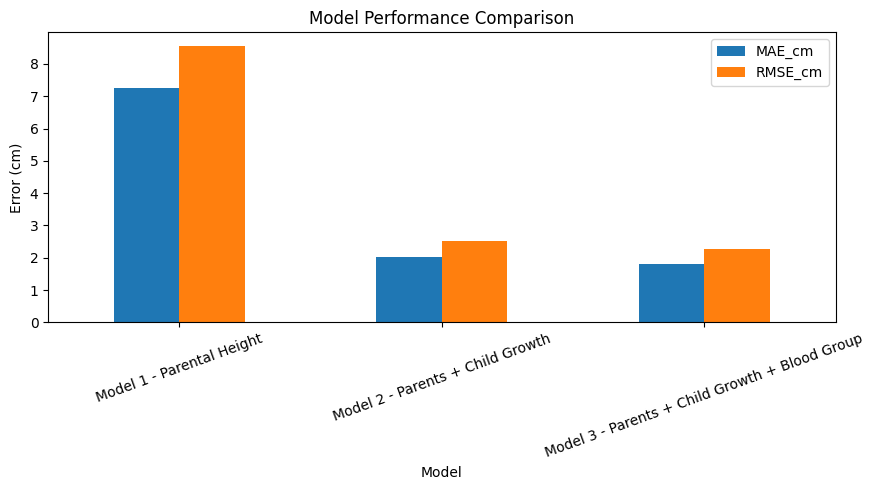

In [ ]:
# ============================================================
#  MODEL PERFORMANCE GRAPH
# ============================================================

import matplotlib.pyplot as plt

final_comparison.set_index("Model")[["MAE_cm", "RMSE_cm"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel("Error (cm)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

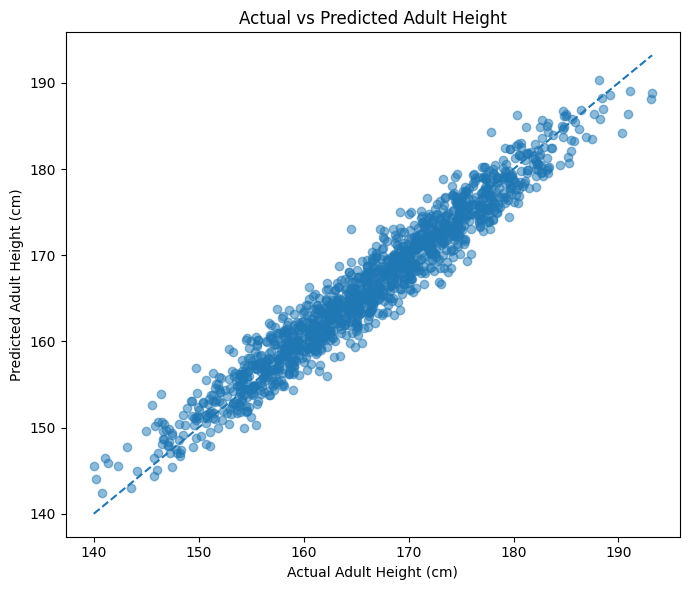

In [ ]:
# ============================================================
# CELL 45: ACTUAL VS PREDICTED ADULT HEIGHT
# ============================================================

# PURPOSE:
# Compare the actual adult height with the height predicted
# by our best Random Forest model.

plt.figure(figsize=(7, 6))

plt.scatter(y_test, pred_3, alpha=0.5)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adult Height (cm)")
plt.ylabel("Predicted Adult Height (cm)")
plt.title("Actual vs Predicted Adult Height")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  FEATURE IMPORTANCE
# ============================================================

# PURPOSE:
# Identify which features contributed most to the
# Random Forest prediction of final adult height.

importance = pd.DataFrame({
    "Feature": X_model3.columns,
    "Importance": model_3.feature_importances_
})

# Sort from most important to least important.
importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
print(importance)

Feature Importance:
                        Feature  Importance
12               Child_Sex_Male    0.314223
5       Child_Current_Height_cm    0.274184
11             Child_Sex_Female    0.196833
4               Child_Age_Years    0.152056
0              Father_Height_cm    0.015891
1              Mother_Height_cm    0.010972
10  Growth_Velocity_cm_per_year    0.008687
8               Birth_Weight_kg    0.004851
9               Birth_Length_cm    0.004698
2              Father_Age_Years    0.004536
3              Mother_Age_Years    0.004362
7                     Child_BMI    0.003306
6       Child_Current_Weight_kg    0.003123
13               Blood_Group_A+    0.000680
19               Blood_Group_O+    0.000652
17               Blood_Group_B+    0.000541
15              Blood_Group_AB+    0.000242
20               Blood_Group_O-    0.000064
14               Blood_Group_A-    0.000041
16              Blood_Group_AB-    0.000033
18               Blood_Group_B-    0.000027


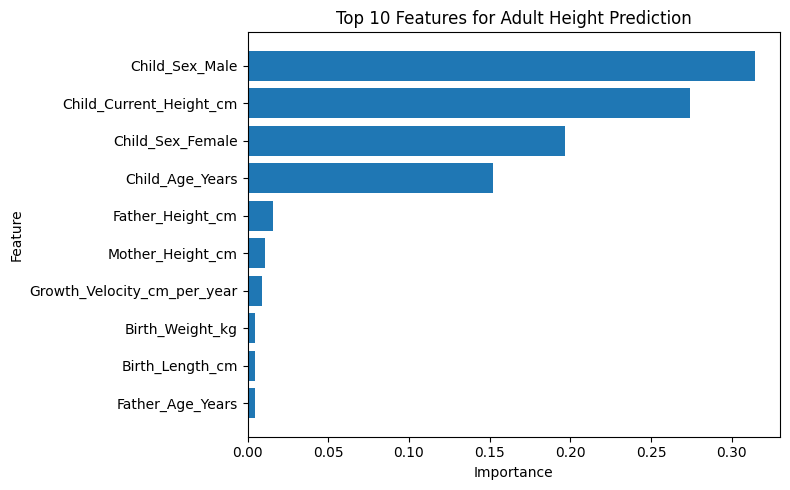

In [ ]:
# ============================================================
#  FEATURE IMPORTANCE GRAPH
# ============================================================

# Show the 10 most important features.

top_features = importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Adult Height Prediction")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  ACTUAL VS PREDICTED VALUES
# ============================================================

# PURPOSE:
# Display a few real test cases and compare their
# actual adult height with the Random Forest prediction.

results = pd.DataFrame({
    "Actual_Height_cm": y_test.values,
    "Predicted_Height_cm": pred_3
})

# Calculate the prediction error.
results["Error_cm"] = (
    results["Actual_Height_cm"] -
    results["Predicted_Height_cm"]
)

# Display the first 10 predictions.
results.head(10)

,Actual_Height_cm,Predicted_Height_cm,Error_cm
0,163.0,163.5130,-0.5130
1,152.7,151.6410,1.0590
2,162.2,161.8740,0.3260
3,182.7,183.6325,-0.9325
4,158.7,158.9960,-0.2960
5,150.7,151.5095,-0.8095
6,145.7,146.4905,-0.7905
7,176.8,175.7060,1.0940
8,171.6,172.1410,-0.5410
9,174.1,177.0440,-2.9440


In [ ]:
# ============================================================
#  FINAL PROJECT SUMMARY
# ============================================================

print("========== FINAL PROJECT RESULT ==========")

print("\nBest Algorithm:")
print("Random Forest Regression")

print("\nBest Model Performance:")
print("MAE :", mae_3, "cm")
print("RMSE:", rmse_3, "cm")
print("R²  :", r2_3)

print("\nMain conclusion:")
print(
    "Parental height alone was less accurate than models "
    "that also considered child growth information."
)

print(
    "The Random Forest model using parental characteristics, "
    "child growth variables and blood group gave the best "
    "performance among the three tested models."
)

========== FINAL PROJECT RESULT ==========

Best Algorithm:
Random Forest Regression

Best Model Performance:
MAE : 1.8144242857142867 cm
RMSE: 2.2713098207390647 cm
R²  : 0.9419349095368393

Main conclusion:
Parental height alone was less accurate than models that also considered child growth information.
The Random Forest model using parental characteristics, child growth variables and blood group gave the best performance among the three tested models.
